In [8]:
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf



In [ ]:
pip install matplotlib

In [5]:
# Load the already-saved model
model = load_model("models/fashion_cnn.keras")   # ← already exists!

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("✅ Model loaded:", model.input_shape)

✅ Model loaded: (None, 28, 28, 1)


In [6]:
def predict_clothing(image_source):
    """
    image_source: file path (str) OR PIL Image object
    """
    if isinstance(image_source, str):
        img = Image.open(image_source)
    else:
        img = image_source

    img   = img.convert("L").resize((28, 28))
    arr   = np.array(img) / 255.0
    arr   = arr.reshape(1, 28, 28, 1)
    preds = model.predict(arr, verbose=0)[0]

    top3_idx = preds.argsort()[-3:][::-1]
    return {
        "label"      : class_names[top3_idx[0]],
        "confidence" : float(preds[top3_idx[0]]),
        "top3"       : [(class_names[i], float(preds[i])) for i in top3_idx]
    }


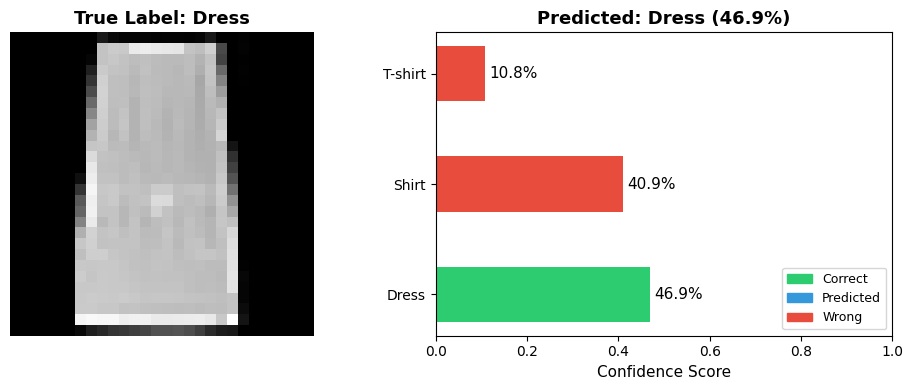

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ── Left: show the image ──────────────────────────────────────────────────────
axes[0].imshow(X_test[sample_idx], cmap="gray")
axes[0].set_title(f"True Label: {class_names[y_test[sample_idx]]}", 
                  fontsize=13, fontweight="bold")
axes[0].axis("off")

# ── Right: confidence bar chart ───────────────────────────────────────────────
labels = [t[0] for t in result["top3"]]
scores = [t[1] for t in result["top3"]]
colors = ["#2ecc71" if l == class_names[y_test[sample_idx]] else "#e74c3c" 
          if l != result["label"] else "#3498db" for l in labels]

bars = axes[1].barh(labels, scores, color=colors, height=0.5)
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("Confidence Score", fontsize=11)
axes[1].set_title(f"Predicted: {result['label']} ({result['confidence']:.1%})", 
                  fontsize=13, fontweight="bold")

for bar, score in zip(bars, scores):
    axes[1].text(score + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{score:.1%}", va="center", fontsize=11)

# ── Legend ────────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend = [Patch(color="#2ecc71", label="Correct"), 
          Patch(color="#3498db", label="Predicted"),
          Patch(color="#e74c3c", label="Wrong")]
axes[1].legend(handles=legend, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("prediction_result.png", dpi=150, bbox_inches="tight")
plt.show()


/var/folders/rs/k45t2h054lqgqjn4nhrz30p00000gp/T/ipykernel_3684/183956391.py:21: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/rs/k45t2h054lqgqjn4nhrz30p00000gp/T/ipykernel_3684/183956391.py:22: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.savefig("batch_tagging.png", dpi=150, bbox_inches="tight")
/Users/sunerawanni/Desktop/databricks/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


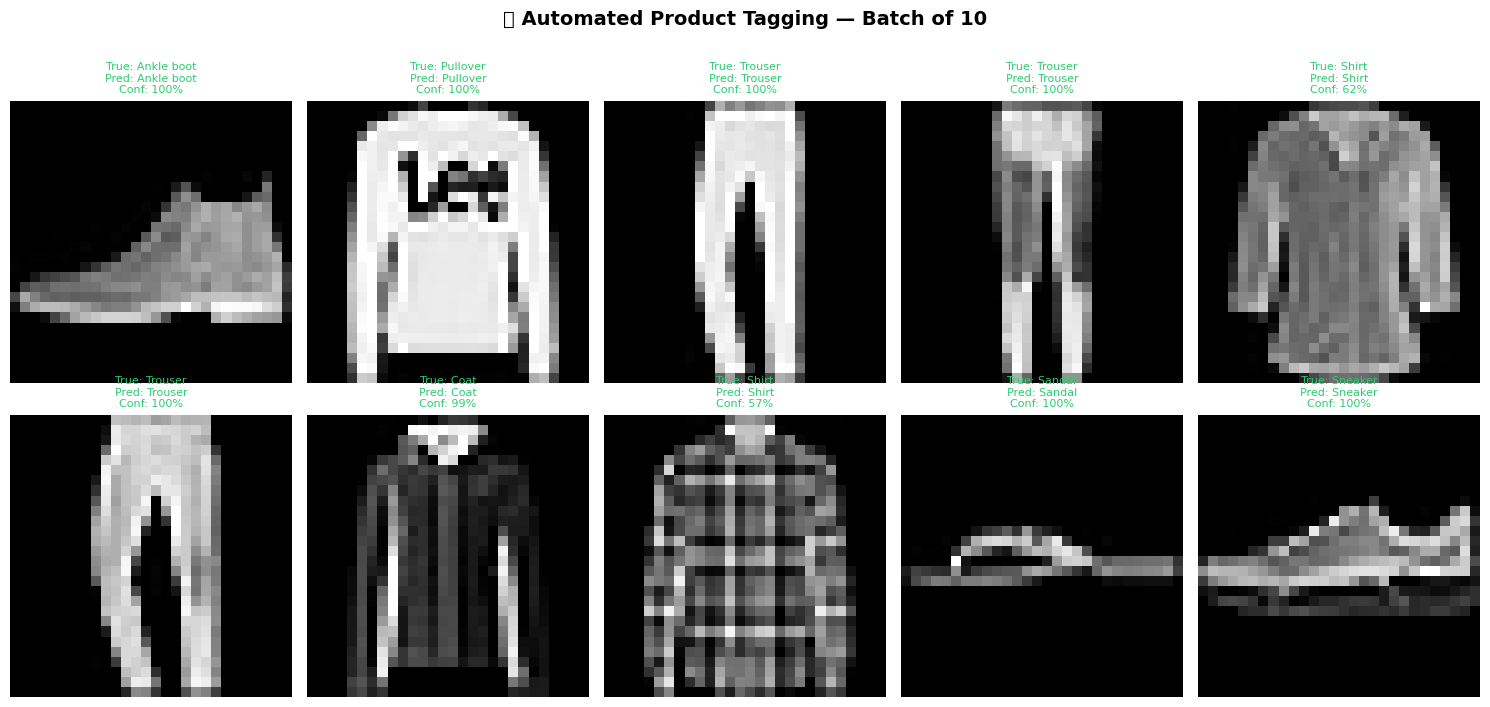


Batch accuracy: 10/10 correct


In [11]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for i in range(10):
    img    = Image.fromarray(X_test[i])
    result = predict_clothing(img)
    true   = class_names[y_test[i]]
    correct = result["label"] == true
    color  = "#2ecc71" if correct else "#e74c3c"

    axes[i].imshow(X_test[i], cmap="gray")
    axes[i].set_title(
        f"True: {true}\nPred: {result['label']}\nConf: {result['confidence']:.0%}",
        fontsize=8,
        color=color
    )
    axes[i].axis("off")

plt.suptitle("🏷️ Automated Product Tagging — Batch of 10", 
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("batch_tagging.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary
correct_count = sum(
    1 for i in range(10)
    if predict_clothing(Image.fromarray(X_test[i]))["label"] == class_names[y_test[i]]
)
print(f"\nBatch accuracy: {correct_count}/10 correct")


In [12]:
results = []
for i in range(100):
    img    = Image.fromarray(X_test[i])
    result = predict_clothing(img)
    true   = class_names[y_test[i]]
    results.append({
        "true"      : true,
        "predicted" : result["label"],
        "confidence": result["confidence"],
        "correct"   : result["label"] == true
    })

import pandas as pd
results_df = pd.DataFrame(results)

print(f"Accuracy on 100 samples: {results_df['correct'].mean():.1%}")
print(f"Avg confidence: {results_df['confidence'].mean():.1%}")
print(f"\nPer-class accuracy:")
print(results_df.groupby("true")["correct"].mean().sort_values())


Accuracy on 100 samples: 89.0%
Avg confidence: 91.1%

Per-class accuracy:
true
Ankle boot    0.666667
Coat          0.800000
Sneaker       0.818182
Pullover      0.857143
Shirt         0.875000
T-shirt       0.875000
Dress         0.888889
Bag           1.000000
Sandal        1.000000
Trouser       1.000000
Name: correct, dtype: float64
